In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, roc_auc_score, precision_score, recall_score, f1_score, roc_curve, classification_report, confusion_matrix
import joblib


In [2]:
clean_df = pd.read_csv('cleaned.csv')

# preprocessing + class weights

In [ ]:
# Features and labels
X = clean_df.drop(columns=['status']).values
y = clean_df['status'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardization (works fine with negative values)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Compute class weights
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weights = dict(zip(classes, class_weights))

print("Class Weights:", class_weights)

Class Weights: {np.int64(0): np.float64(1.2594897197025718), np.int64(1): np.float64(0.8291683791294817)}


# ANN Model

In [ ]:
# Define the model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') 
])
# Compile
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train with class weights
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f}")


Epoch 1/10
21184/21184 ━━━━━━━━━━━━━━━━━━━━ 70s 3ms/step - accuracy: 0.9924 - loss: 0.0212 - val_accuracy: 0.9990 - val_loss: 0.0032
Epoch 2/10
21184/21184 ━━━━━━━━━━━━━━━━━━━━ 66s 3ms/step - accuracy: 0.9977 - loss: 0.0070 - val_accuracy: 0.9984 - val_loss: 0.0045
Epoch 3/10
21184/21184 ━━━━━━━━━━━━━━━━━━━━ 97s 5ms/step - accuracy: 0.9982 - loss: 0.0057 - val_accuracy: 0.9994 - val_loss: 0.0020
Epoch 4/10
21184/21184 ━━━━━━━━━━━━━━━━━━━━ 70s 3ms/step - accuracy: 0.9985 - loss: 0.0049 - val_accuracy: 0.9994 - val_loss: 0.0019
Epoch 5/10
21184/21184 ━━━━━━━━━━━━━━━━━━━━ 111s 5ms/step - accuracy: 0.9986 - loss: 0.0044 - val_accuracy: 0.9995 - val_loss: 0.0017
Epoch 6/10
21184/21184 ━━━━━━━━━━━━━━━━━━━━ 95s 4ms/step - accuracy: 0.9987 - loss: 0.0044 - val_accuracy: 0.9995 - val_loss: 0.0015
Epoch 7/10
21184/21184 ━━━━━━━━━━━━━━━━━━━━ 115s 5ms/step - accuracy: 0.9988 - loss: 0.0040 - val_accuracy: 0.9994 - val_loss: 0.0017
Epoch 8/10
21184/21184 ━━━━━━━━━━━━━━━━━━━━ 99s 5ms/step - accuracy

5296/5296 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


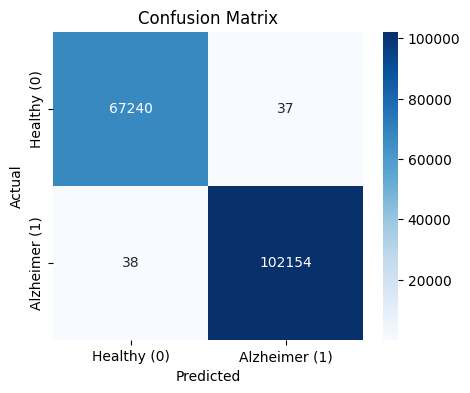

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     67277
           1       1.00      1.00      1.00    102192

    accuracy                           1.00    169469
   macro avg       1.00      1.00      1.00    169469
weighted avg       1.00      1.00      1.00    169469



In [ ]:
# Predictions
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy (0)', 'Alzheimer (1)'],
            yticklabels=['Healthy (0)', 'Alzheimer (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))


5296/5296 ━━━━━━━━━━━━━━━━━━━━ 3s 598us/step
R2 Score: 0.9986
Mean Squared Error: 0.0003
Mean Absolute Error: 0.0007
ROC AUC: 1.0000
Precision: 0.9996
Recall: 0.9996
F1 Score: 0.9996


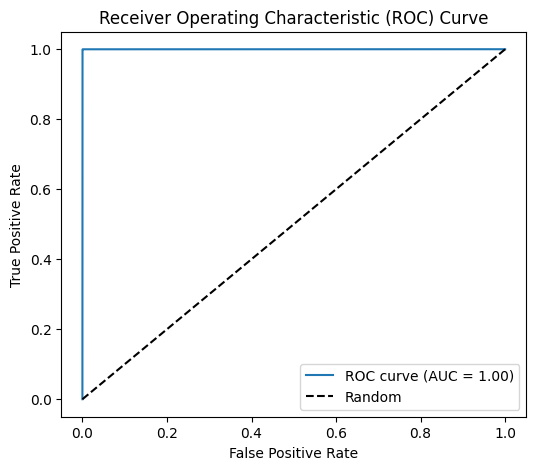

In [ ]:
# R2, MSE, MAE (regression metrics, but can be informative for probability outputs)
y_prob = model.predict(X_test).flatten()
r2 = r2_score(y_test, y_prob)
mse = mean_squared_error(y_test, y_prob)
mae = mean_absolute_error(y_test, y_prob)

# Classification metrics
roc_auc = roc_auc_score(y_test, y_prob)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"R2 Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# ROC Curve Visualization
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [ ]:
# Save the fitted scaler
joblib.dump(scaler, "scaler.pkl")
print("Scaler saved as scaler.pkl")

Scaler saved as scaler.pkl


In [ ]:
# Save model
model.save("alzheimers_model.h5")

In [ ]:
# load model:
from tensorflow.keras.models import load_model
model = load_model("alzheimers_model.h5")

In [ ]:
# predict function for user input
def predict_user_input(user_input, model, scaler, input_dim):
    if len(user_input) == input_dim:
        sample = np.array(user_input).reshape(1, -1)
        sample_scaled = scaler.transform(sample)
        output = model.predict(sample_scaled)
        predicted_class = int(output[0][0] > 0.5)
        print(f"Model output (probability): {output[0][0]:.4f}")
        print(f"Predicted class: {predicted_class}")
        return output[0][0], predicted_class
    else:
        print(f"Please provide {input_dim} input values in user_input.")
        return None

### Testing

In [16]:
input_dim = X.shape[1]
user_input = [-67.2, 144.2, -140.8, -23.2, -305.5, -94.6, 83.3, -114.4, 24.2, 66, 148.5, -33.7, -40.7, -21.7, 343.1, 32.5]
predict_user_input(user_input, model, scaler, input_dim)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Model output (probability): 0.0000
Predicted class: 0


(np.float32(0.0), 0)

In [17]:
user_input = [-96.1125, -18.9125, -21.1125, -18.7125, 42.8875, 16.3875, 326.4875, -80.6125, -22.3125, -28.5125, -56.3125, -8.4125, -22.6125, -52.2125, 84.3875, -44.3125]
predict_user_input(user_input, model, scaler, input_dim)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Model output (probability): 1.0000
Predicted class: 1


(np.float32(1.0), 1)